# Johansen Test on a Crypto Basket

This notebook applies the Johansen cointegration test to a basket of shared crypto close-price fixtures.

Chan's reason for using Johansen is practical: CADF is pairwise and order dependent, while Johansen can test a multivariate system and returns eigenvectors that can be used as hedge ratios.

The notebook reads local fixtures only. Refresh fixtures with:

```bash
python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import coint_johansen

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [ ]:
def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )

repo_root = find_repo_root()
fixture_path = repo_root / "fixtures/crypto/crypto_daily_close.csv"

close = pd.read_csv(fixture_path, parse_dates=["date"]).set_index("date").sort_index()
close = close.apply(pd.to_numeric, errors="coerce").dropna(how="all")

basket_symbols = ["BTCUSDT", "ETHUSDT", "BNBUSDT"]
missing = [symbol for symbol in basket_symbols if symbol not in close]
if missing:
    raise ValueError(f"Fixture is missing required symbols: {missing}")

prices = close[basket_symbols].dropna()
log_prices = np.log(prices)

log_prices.tail()


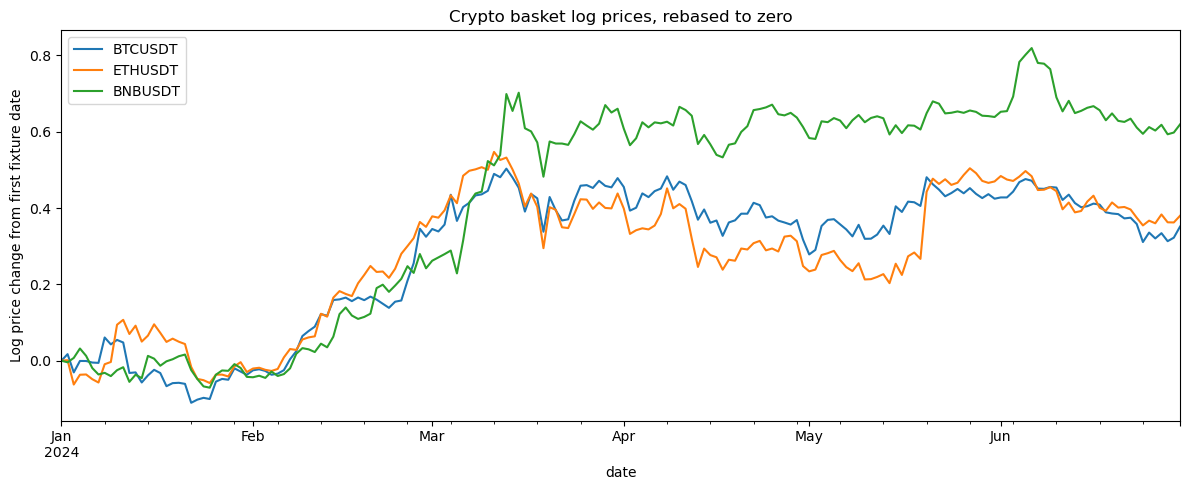

In [3]:
rebased = log_prices - log_prices.iloc[0]
rebased.plot(figsize=(12, 5), title="Crypto basket log prices, rebased to zero")
plt.ylabel("Log price change from first fixture date")
plt.tight_layout();

In [4]:
# det_order=0 allows a constant term in the cointegration relation.
# k_ar_diff=1 mirrors the one-lag setup used in Chan's examples.
johansen = coint_johansen(log_prices, det_order=0, k_ar_diff=1)

rank_table = pd.DataFrame(
    {
        "null_rank_at_most": range(len(basket_symbols)),
        "trace_stat": johansen.lr1,
        "trace_crit_90pct": johansen.cvt[:, 0],
        "trace_crit_95pct": johansen.cvt[:, 1],
        "trace_crit_99pct": johansen.cvt[:, 2],
        "max_eigen_stat": johansen.lr2,
        "max_eigen_crit_90pct": johansen.cvm[:, 0],
        "max_eigen_crit_95pct": johansen.cvm[:, 1],
        "max_eigen_crit_99pct": johansen.cvm[:, 2],
    }
)
rank_table["trace_reject_95pct"] = rank_table["trace_stat"] > rank_table["trace_crit_95pct"]
rank_table["max_eigen_reject_95pct"] = rank_table["max_eigen_stat"] > rank_table["max_eigen_crit_95pct"]

rank_table

,null_rank_at_most,trace_stat,trace_crit_90pct,trace_crit_95pct,trace_crit_99pct,max_eigen_stat,max_eigen_crit_90pct,max_eigen_crit_95pct,max_eigen_crit_99pct,trace_reject_95pct,max_eigen_reject_95pct
0,0,34.667017,27.066900,29.796100,35.462800,20.857769,18.892800,21.131400,25.865000,True,False
1,1,13.809248,13.429400,15.494300,19.934900,11.658392,12.297100,14.263900,18.520000,False,False
2,2,2.150857,2.705500,3.841500,6.634900,2.150857,2.705500,3.841500,6.634900,False,False


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rank_table.set_index("null_rank_at_most")[["trace_stat", "trace_crit_95pct"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Johansen trace test versus 95% critical value")
axes[0].set_xlabel("null rank at most")
axes[0].set_ylabel("statistic")
axes[0].tick_params(axis="x", rotation=0)

rank_table.set_index("null_rank_at_most")[["max_eigen_stat", "max_eigen_crit_95pct"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Max-eigen test versus 95% critical value")
axes[1].set_xlabel("null rank at most")
axes[1].set_ylabel("statistic")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout();


In [5]:
hedge_ratios = pd.DataFrame(
    johansen.evec,
    index=basket_symbols,
    columns=[f"relation_{i + 1}" for i in range(johansen.evec.shape[1])],
)

# Normalize each relation so BTC has unit weight. This changes scale, not the portfolio.
normalized_hedges = hedge_ratios.divide(hedge_ratios.loc["BTCUSDT"], axis=1)
normalized_hedges

,relation_1,relation_2,relation_3
BTCUSDT,1.000000,1.000000,1.000000
ETHUSDT,-0.398464,-2.004529,-0.502688
BNBUSDT,-0.457220,0.374513,0.055599


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
normalized_hedges.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Johansen eigenvectors normalized to BTC = 1")
ax.set_ylabel("portfolio weight")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout();


,portfolio_weight
BTCUSDT,1.000000
ETHUSDT,-0.398464
BNBUSDT,-0.457220


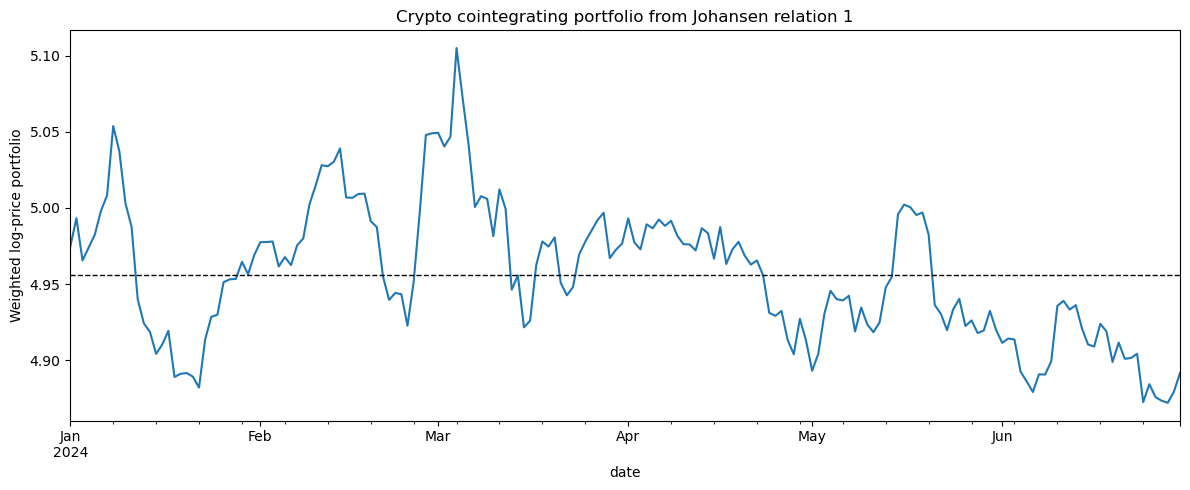

In [6]:
selected_relation = "relation_1"
weights = normalized_hedges[selected_relation]
portfolio = log_prices @ weights
portfolio.name = "cointegrating_portfolio"

portfolio.plot(figsize=(12, 5), title="Crypto cointegrating portfolio from Johansen relation 1")
plt.axhline(portfolio.mean(), color="black", linestyle="--", linewidth=1)
plt.ylabel("Weighted log-price portfolio")
plt.tight_layout();

weights.to_frame("portfolio_weight")

In [ ]:
portfolio_z = (portfolio - portfolio.mean()) / portfolio.std()

fig, ax = plt.subplots(figsize=(12, 5))
portfolio_z.plot(ax=ax, color="tab:purple", linewidth=2)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="tab:red", linestyle="--", linewidth=1)
ax.axhline(-2, color="tab:red", linestyle="--", linewidth=1)
ax.set_title("Cointegrating portfolio z-score")
ax.set_ylabel("z-score")
plt.tight_layout();


In [7]:
def estimate_half_life(series: pd.Series) -> pd.Series:
    y = pd.Series(series).dropna()
    reg_df = pd.DataFrame({"lagged": y.shift(1), "delta": y.diff()}).dropna()
    design = np.column_stack([np.ones(len(reg_df)), reg_df["lagged"].to_numpy()])
    intercept, lambda_hat = np.linalg.lstsq(design, reg_df["delta"].to_numpy(), rcond=None)[0]

    half_life = np.nan if lambda_hat >= 0 else -np.log(2) / lambda_hat
    return pd.Series(
        {
            "intercept": intercept,
            "lambda": lambda_hat,
            "half_life_days": half_life,
            "observations": len(reg_df),
            "mean_reverting_lambda": lambda_hat < 0,
        }
    )

In [8]:
half_life_summary = estimate_half_life(portfolio)
half_life_summary.to_frame("value")

,value
intercept,0.357054
lambda,-0.072129
half_life_days,9.609858
observations,181
mean_reverting_lambda,True


## Interpretation

The rank table asks how many independent stationary relations survive the Johansen critical values. The eigenvectors then provide candidate hedge ratios. After selecting a relation, the resulting portfolio can be studied exactly like the spreads in Section 2.1: estimate pullback speed and translate it into a half-life.